<a href="https://colab.research.google.com/github/haymanguddanti/Receipt-Data-Extraction/blob/main/code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Receipt Data Extraction and SQL Generation

### Install Dependencies

In [39]:
!pip install easyocr
!pip install google-genai
!pip install pillow

### Import Libraries

In [40]:
import easyocr
from PIL import Image
import google.generativeai as genai

### Upload Receipt Image

Saving sample.png to sample.png
Uploaded: sample.png


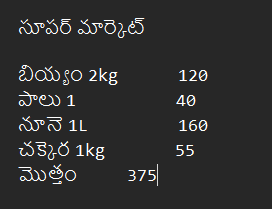

In [41]:
from google.colab import files

uploaded = files.upload()

image_path = list(uploaded.keys())[0]
# image_path = "sample.png"
print("Uploaded:", image_path)
display(Image.open(image_path))

### Perform OCR on the Uploaded Image

In [42]:
print("OCR model")

reader = easyocr.Reader(['te','en'])

result = reader.readtext(image_path, detail=0)

ocr_text = "\n".join(result)

print("\nOCR OUTPUT\n")
print(ocr_text)

OCR model


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



OCR OUTPUT

సూపర్ మార్కెట్
బియ్యం 2kg
120
పాలు1
40
నూనె 1L
160
చక్కెర 1kg
55
మొ
375


### Configure Gemini API Client

In [43]:
genai.configure(api_key="gemini_api_key")
client = genai.GenerativeModel("gemini-3-flash-preview")

### Generate SQL Queries using the Model

In [45]:
prompt = f"""
You are an intelligent receipt parser.

Given Telugu OCR text:

1. Translate into English.
2. Extract items, quantity, price.
3. Generate SQL INSERT queries.

Table schema:

CREATE TABLE receipts(
    item_name TEXT,
    quantity TEXT,
    price amount
);

OCR TEXT:
{ocr_text}

Return ONLY SQL queries.
"""

response = client.generate_content(
    contents=prompt
)

sql_output = response.text

print("\nGENERATED SQL\n")
print(sql_output)


GENERATED SQL

INSERT INTO receipts (item_name, quantity, price) VALUES ('Rice', '2kg', 120);
INSERT INTO receipts (item_name, quantity, price) VALUES ('Milk', '1', 40);
INSERT INTO receipts (item_name, quantity, price) VALUES ('Oil', '1L', 160);
INSERT INTO receipts (item_name, quantity, price) VALUES ('Sugar', '1kg', 55);
